# Statistical Router — National Backtest (Step 05, steps 2 & 3)

> ## READ THIS FIRST — what this notebook is, and is NOT
>
> **Its ONE job: decide WHICH simple forecasting method to trust for each county's behaviour regime.**
> That is the whole exercise — *"for this kind of county, which expert predicts next year best?"*
>
> - This is a **selection / validation** step. The **backtest** here (train on past years → predict a
>   HELD-OUT year → score it) exists only to *prove*, out-of-sample, which method beats today's
>   historical mean. **The backtest is NOT what ships and is NOT run in production.**
> - **What ships is a forward-looking adjustment factor**, produced separately by applying the *chosen*
>   method to ALL observed history:
>   `λ_forward = chosen_expert(full history)` · `factor = λ_forward / λ_history` (capped, shadow).
>   **No backtest in production — you use every year you have.** Once the method is picked, the live
>   number is dead simple.
> - **Today the method is purely statistical** (the county's own counts only). Climate / grid / weather
>   are a **later challenger layer** that must beat this statistical baseline before being added.
> - **Data hygiene:** everything below runs ONLY on **source-coverage-MASKED observed years** — missing /
>   ramp years are dropped, never treated as observed zeros (see §01). *Open caveat:* the mask is the
>   all-duration proxy (A016); whether it fully removes early-year coverage ramp is the coverage check we flagged.

**How we evaluate (the backtest used for selection).**
```
  · rolling-origin, leakage-free:  train on observed years < Y, predict Y, for Y in 2020..2025
  · baseline = TODAY's flat mean (not a hindsight "best single global" method)
  · EQUAL-WEIGHT across county-cells (every (county, trigger) counts the same).
    We do NOT pool nationally by event volume — that is dominated by a few mega-counties and
    hides the per-bucket story (which is the whole point of routing).
```

Non-goals: no active pricing change, no dashboard code, no weather/climate/grid covariates yet.
Decisions D1–D4 and the 4-step ladder live in the plan
(`docs/plan/05_forward_regime/statistical_router/01_notebook_plan.md`).

## §00 — Setup & resolved paths

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT/"curated_outage_data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CATALOG = "eagle-i-45min"; TRIGGERS = [2,4,8,12,24]
TREND  = ROOT/f"curated_outage_data/outputs/county_trend/county_yearly_trend__{CATALOG}.parquet"
REGIME = ROOT/"notebooks/outputs/regime_classification/county_regime_T8.csv"
OUT    = ROOT/"notebooks/outputs/forward_regime/statistical_router"; OUT.mkdir(parents=True, exist_ok=True)
print("ROOT      :", ROOT)
print("trend     :", TREND.exists(), TREND.name)
print("regime    :", REGIME.exists(), REGIME.name)
print("triggers  :", TRIGGERS, "| baseline = flat mean | weighting = equal per county-cell")

ROOT      : /Users/divy/code/work/infrasure_git_codes/outage_pricing
trend     : True county_yearly_trend__eagle-i-45min.parquet
regime    : True county_regime_T8.csv
triggers  : [2, 4, 8, 12, 24] | baseline = flat mean | weighting = equal per county-cell


## §01 — Load annual counts & apply the observed-year mask
Missing/ramp years are **not** observed zeros.

In [2]:
tr = pd.read_parquet(TREND); tr["fips"] = tr["fips"].astype(str).str.zfill(5)
def observed(row):
    y = np.asarray(row["years"], float); c = np.asarray(row["yearly_counts"], float)
    m = np.asarray(row["observed_year_mask"], bool)
    return y[m], c[m]
n_obs = tr["observed_year_mask"].apply(lambda m: int(np.sum(m)))
print(f"rows {len(tr):,} = {tr.fips.nunique()} counties x {tr['T'].nunique()} triggers")
print("observed years per cell — by trigger:")
print(pd.DataFrame({"T": tr['T'], "n_obs": n_obs}).groupby("T")["n_obs"].agg(["mean","min","max"]).round(2))

rows 15,450 = 3090 counties x 5 triggers
observed years per cell — by trigger:
     mean  min  max
T                  
2   10.31    0   11
4   10.31    0   11
8   10.31    0   11
12  10.31    0   11
24  10.31    0   11


## §02 — Join the Step-3 regime label (one per county, 8h-anchored, A014)

In [3]:
reg = pd.read_csv(REGIME, dtype={"fips": str}); reg["fips"] = reg["fips"].str.zfill(5)
reg_map = reg.set_index("fips")["regime"].to_dict()
print("regime mix (county-level):"); print(reg["regime"].value_counts().to_string())
print("\nNote: nationally we DO have 47 episodic counties (the Northeast pilot had 0).")

regime mix (county-level):
regime
stable          1306
trend            718
shift            675
insufficient     344
episodic          47

Note: nationally we DO have 47 episodic counties (the Northeast pilot had 0).


## §03 — The candidate experts
Every expert is a function of the county's **own** training counts — nothing external.
- **flat** = mean of all train years (today's method) · **recent_k3 / recent_k5** = mean of last 3 / 5
- **wtd_recent** = exponentially-weighted recent mean · **linear / capped_lin / theil_sen** = slope extrapolation (capped / robust)
- **persist** = last observed year · **changept** = detect a level break, forecast the post-break mean

In [4]:
def flat_mean(yr,y,ny): return float(np.mean(y))
def recent_k3(yr,y,ny):  return float(np.mean(y[-3:]))
def recent_k5(yr,y,ny):  return float(np.mean(y[-5:]))
def wtd_recent(yr,y,ny,a=0.6):
    w = a**(np.arange(len(y))[::-1]); return float(np.sum(w*y)/np.sum(w))
def linear(yr,y,ny):
    b,a = np.polyfit(yr,y,1); return float(max(0.0, a+b*ny))
def capped_lin(yr,y,ny):
    m = np.mean(y); return float(np.clip(linear(yr,y,ny), 0.5*m, 2.0*m))
def theil_sen(yr,y,ny):
    n=len(y); sl=[(y[j]-y[i])/(yr[j]-yr[i]) for i in range(n) for j in range(i+1,n) if yr[j]!=yr[i]]
    if not sl: return float(np.mean(y))
    b=np.median(sl); a=np.median(np.asarray(y)-b*np.asarray(yr)); return float(max(0.0,a+b*ny))
def persist(yr,y,ny): return float(y[-1])
def changept(yr,y,ny):
    n=len(y); m=float(np.mean(y))
    if n<6: return m
    base=float(np.sum((y-m)**2)); best=None
    for s in range(3,n-2):
        pre,post=y[:s],y[s:]; sse=float(np.sum((pre-pre.mean())**2)+np.sum((post-post.mean())**2))
        if best is None or sse<best[0]: best=(sse,float(post.mean()),abs(post.mean()-pre.mean()))
    return best[1] if (best and best[0]<0.7*base and best[2]>0.5*np.std(y)) else m
EXPERTS={"flat":flat_mean,"recent_k3":recent_k3,"recent_k5":recent_k5,"wtd_recent":wtd_recent,
         "linear":linear,"capped_lin":capped_lin,"theil_sen":theil_sen,"persist":persist,"changept":changept}
EN=list(EXPERTS); print("experts:", EN)

experts: ['flat', 'recent_k3', 'recent_k5', 'wtd_recent', 'linear', 'capped_lin', 'theil_sen', 'persist', 'changept']


### §03b — Unit-test each expert on synthetic mini-series (correctness before trust)

In [5]:
yr=np.arange(2015,2025.0)
def near(a,b,t=1e-6): assert abs(a-b)<t, (a,b)
near(flat_mean(yr,np.full(10,5.0),2025), 5.0)                       # stable -> the level
near(persist(yr,np.array([1,2,3,4,5,6,7,8,9,10.0]),2025), 10.0)     # persistence -> last
near(recent_k3(yr,np.array([0,0,0,0,0,0,0,9,9,9.0]),2025), 9.0)     # recent step -> new level
near(linear(yr,np.arange(10.0)+1,2025), 11.0)                       # perfect slope 1 -> extends
assert capped_lin(yr,np.array([1,1,1,1,1,1,1,1,1,100.0]),2025) <= 2.0*np.mean([1]*9+[100])+1e-9  # cap holds
assert changept(yr,np.array([2,2,2,2,2,9,9,9,9,9.0]),2025)==9.0     # clean break -> post mean
print("expert unit tests PASS")

expert unit tests PASS


## §04 — Rolling-origin backtest → per-cell WAPE
For each (county, trigger) and each test year, every expert forecasts from train years < test year.
We store **per-cell WAPE** (`sum|pred-obs| / sum obs` over that cell's folds) so we can weight every
county-cell **equally** afterwards. A cell needs ≥2 folds and ≥5 total events to be scored.

In [6]:
MIN_TRAIN=4; rows=[]; preds=[]
for _,r in tr.iterrows():
    fips,T=r["fips"],int(r["T"]); regime=reg_map.get(fips)
    if regime is None: continue
    oy,oc=observed(r)
    ae={e:0.0 for e in EN}; sob=0.0; nf=0
    for ty in range(2020,2026):
        if ty not in oy: continue
        m=oy<ty
        if m.sum()<MIN_TRAIN: continue
        ytr,ctr=oy[m],oc[m]; obs=float(oc[oy==ty][0]); sob+=obs; nf+=1
        for e in EN:
            p=EXPERTS[e](ytr,ctr,float(ty)); ae[e]+=abs(p-obs)
            preds.append((fips,T,ty,regime,e,obs,p))
    if nf>=2 and sob>=5:
        for e in EN: rows.append((fips,T,regime,e,ae[e]/sob))
C=pd.DataFrame(rows,columns=["fips","T","regime","expert","wape_cell"])
P=pd.DataFrame(preds,columns=["fips","T","year","regime","expert","obs","pred"])
ncells=C.groupby(["fips","T"]).ngroups
print(f"scored county-cells: {ncells:,}  | backtest predictions: {len(P):,}")
print("median per-cell WAPE by trigger (typical cell, equal-weight):")
print(C[C.expert=='flat'].groupby('T')['wape_cell'].median().round(3).to_string())

scored county-cells: 14,383  | backtest predictions: 772,650
median per-cell WAPE by trigger (typical cell, equal-weight):
T
2     0.230
4     0.292
8     0.365
12    0.415
24    0.515


## §05 — Per-bucket evaluation (EQUAL-WEIGHT): does each regime want a different expert?
Median per-cell WAPE by regime × expert. Lower = better; the per-regime best is highlighted.

median per-cell WAPE (** = best in regime):
  stable        flat:0.317   recent_k3:0.293   recent_k5:0.303   wtd_recent:0.280** linear:0.383   capped_lin:0.363   theil_sen:0.367   persist:0.309   changept:0.298  
  trend         flat:0.379   recent_k3:0.231   recent_k5:0.287   wtd_recent:0.244   linear:0.229   capped_lin:0.225   theil_sen:0.231   persist:0.218** changept:0.255  
  shift         flat:0.344   recent_k3:0.236   recent_k5:0.281   wtd_recent:0.235   linear:0.302   capped_lin:0.287   theil_sen:0.298   persist:0.224** changept:0.257  
  episodic      flat:0.879   recent_k3:1.032   recent_k5:0.928   wtd_recent:0.908   linear:1.270   capped_lin:1.152   theil_sen:1.000   persist:0.833** changept:0.923  
  insufficient  flat:0.522   recent_k3:0.474   recent_k5:0.483   wtd_recent:0.458** linear:0.485   capped_lin:0.484   theil_sen:0.504   persist:0.458   changept:0.477  

best expert per regime: {'stable': 'wtd_recent', 'trend': 'persist', 'shift': 'persist', 'episodic': 'persist'

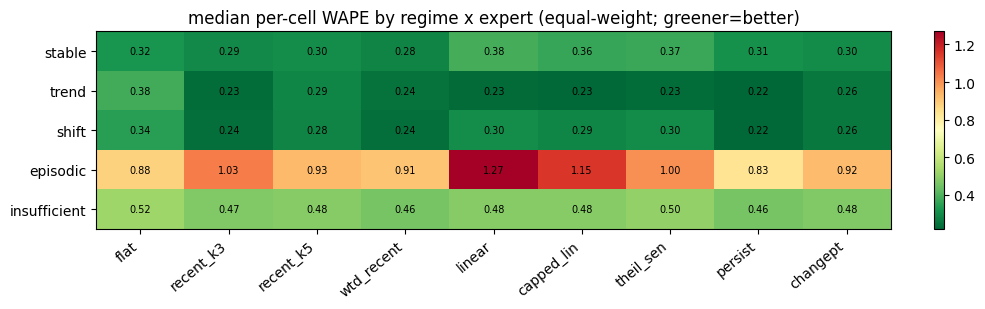

In [7]:
RO=["stable","trend","shift","episodic","insufficient"]
piv=C.groupby(["regime","expert"])["wape_cell"].median().unstack().reindex(RO)[EN]
best_re=piv.idxmin(axis=1).to_dict()
disp=piv.copy()
print("median per-cell WAPE (** = best in regime):")
for rg in RO:
    print(f"  {rg:<13} "+" ".join(f"{e}:{piv.loc[rg,e]:.3f}{'**' if e==best_re[rg] else '  '}" for e in EN))
print("\nbest expert per regime:", best_re)
fig,ax=plt.subplots(figsize=(10,3.2))
im=ax.imshow(piv.values,aspect="auto",cmap="RdYlGn_r")
ax.set_xticks(range(len(EN))); ax.set_xticklabels(EN,rotation=40,ha="right")
ax.set_yticks(range(len(RO))); ax.set_yticklabels(RO)
for i in range(len(RO)):
    for j in range(len(EN)):
        ax.text(j,i,f"{piv.values[i,j]:.2f}",ha="center",va="center",fontsize=7)
ax.set_title("median per-cell WAPE by regime x expert (equal-weight; greener=better)")
plt.colorbar(im,fraction=0.025); plt.tight_layout(); plt.show()

## §06 — Win-rate: how heterogeneous is the best expert within each bucket?
% of county-cells in each regime where each expert has the lowest per-cell WAPE. If one expert
dominated every bucket, routing would be pointless — it does not.

win-rate (% of cells best), top per regime:
  stable        flat 27%  persist 21%  recent_k5 13%  recent_k3 12%
  trend         persist 26%  linear 18%  recent_k3 14%  theil_sen 13%
  shift         persist 39%  recent_k3 14%  wtd_recent 13%  flat 8%
  episodic      persist 43%  flat 25%  recent_k5 7%  wtd_recent 7%
  insufficient  persist 34%  recent_k3 11%  flat 11%  recent_k5 9%


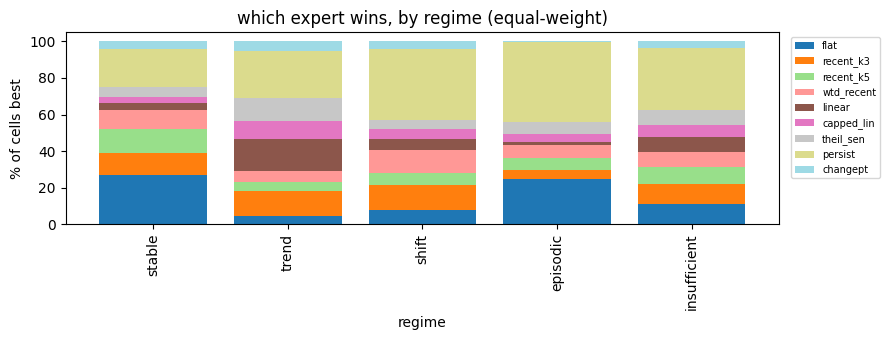

In [8]:
win=C.loc[C.groupby(["fips","T"])["wape_cell"].idxmin()]
wr=win.groupby(["regime","expert"]).size().unstack(fill_value=0)
wr=(wr.div(wr.sum(1),axis=0)*100).reindex(RO)[EN]
print("win-rate (% of cells best), top per regime:")
for rg in RO:
    print(f"  {rg:<13} "+"  ".join(f"{e} {wr.loc[rg,e]:.0f}%" for e in wr.loc[rg].sort_values(ascending=False).head(4).index))
wr.plot(kind="bar",stacked=True,figsize=(9,3.5),colormap="tab20",width=0.8)
plt.ylabel("% of cells best"); plt.title("which expert wins, by regime (equal-weight)")
plt.legend(bbox_to_anchor=(1.01,1),fontsize=7); plt.tight_layout(); plt.show()

## §07 — Routing vs today's flat mean (the honest comparison)
Equal-weight, per county-cell. Router = each cell uses its regime's best expert. Then — for contrast —
the **volume-pooled** national number, with the caveat that it is dominated by a few mega-counties.

In [9]:
flat_cell=C[C.expert=="flat"].set_index(["fips","T"])["wape_cell"]
rout_cell=C[C.apply(lambda x:x.expert==best_re[x.regime],axis=1)].set_index(["fips","T"])["wape_cell"]
j=pd.concat([flat_cell.rename("flat"),rout_cell.rename("router")],axis=1).dropna()
print("EQUAL-WEIGHT (every county-cell counts the same):")
print(f"  typical-cell WAPE  flat {j.flat.median():.3f} -> router {j.router.median():.3f}  "
      f"({(j.flat.median()-j.router.median())/j.flat.median()*100:+.1f}%)")
print(f"  router beats flat in {(j.router<j.flat).mean()*100:.0f}% of cells")
# volume-pooled contrast (event-weighted) — the misleading frame
pool=P.copy(); pool["ae"]=(pool.pred-pool.obs).abs()
fw=pool[pool.expert=="flat"]; pooled_flat=fw.ae.sum()/fw.obs.sum()
rw=pool[pool.apply(lambda x:x.expert==best_re[x.regime],axis=1)]; pooled_rout=rw.ae.sum()/rw.obs.sum()
print(f"\nVOLUME-POOLED (event-weighted; DOMINATED BY MEGA-COUNTIES — shown only as a caveat):")
print(f"  pooled WAPE  flat {pooled_flat:.3f} -> router {pooled_rout:.3f}")
print("  -> the pooled gap is smaller because a handful of huge-volume counties decide it. Not our headline.")

EQUAL-WEIGHT (every county-cell counts the same):
  typical-cell WAPE  flat 0.356 -> router 0.257  (+27.7%)
  router beats flat in 66% of cells



VOLUME-POOLED (event-weighted; DOMINATED BY MEGA-COUNTIES — shown only as a caveat):
  pooled WAPE  flat 0.248 -> router 0.156
  -> the pooled gap is smaller because a handful of huge-volume counties decide it. Not our headline.


## §08 — Hard buckets & honest caveats

In [10]:
# episodic: near-hopeless with simple experts
ep=C[C.regime=="episodic"].groupby("expert")["wape_cell"].median().sort_values()
print("episodic (median per-cell WAPE) — everything is poor:", dict(ep.round(2).head(3)))
# flat-mean bias: is the long-run mean systematically low (counts drifting up)?
bias=(P[P.expert=="flat"].pred.sum()-P[P.expert=="flat"].obs.sum())/P[P.expert=="flat"].obs.sum()
print(f"flat-mean pooled bias: {bias:+.3f}  (negative => mean UNDER-predicts => counts rose 2015->2025)")
print("RESOLVED (coverage gate, 2026-06-24): ~2/3 of this rise is EAGLE-I COVERAGE RAMP (2015-2017")
print("under-counted), not forward signal. Dropping the ramp years cuts the bias from -17% to ~-6%, and")
print("the flat mean becomes nearly as good as recent. => the honest fix is a BASELINE-WINDOW cleanup")
print("(Step 1/2), NOT a forward factor. See:")
print("docs/dicsscssion/eventization_frequency_contract/07_coverage_ramp_baseline_window.md")
# trend experts are competitive IN trend counties (pooled view hid this)
tb=C[C.regime=="trend"].groupby("expert")["wape_cell"].median().sort_values()
print("\ntrend bucket (median per-cell WAPE):", dict(tb.round(3).head(5)))

episodic (median per-cell WAPE) — everything is poor: {'persist': np.float64(0.83), 'flat': np.float64(0.88), 'wtd_recent': np.float64(0.91)}
flat-mean pooled bias: -0.170  (negative => mean UNDER-predicts => counts rose 2015->2025)
RESOLVED (coverage gate, 2026-06-24): ~2/3 of this rise is EAGLE-I COVERAGE RAMP (2015-2017
under-counted), not forward signal. Dropping the ramp years cuts the bias from -17% to ~-6%, and
the flat mean becomes nearly as good as recent. => the honest fix is a BASELINE-WINDOW cleanup
(Step 1/2), NOT a forward factor. See:
docs/dicsscssion/eventization_frequency_contract/07_coverage_ramp_baseline_window.md

trend bucket (median per-cell WAPE): {'persist': np.float64(0.218), 'capped_lin': np.float64(0.225), 'linear': np.float64(0.229), 'recent_k3': np.float64(0.231), 'theil_sen': np.float64(0.231)}


## §09 — Emit shadow artifacts (no pricing change)

In [11]:
C.to_parquet(OUT/"per_cell_wape.parquet")
piv.to_csv(OUT/"median_wape_by_regime_expert.csv")
wr.to_csv(OUT/"winrate_by_regime_expert.csv")
pd.Series(best_re,name="best_expert").rename_axis("regime").to_csv(OUT/"best_expert_by_regime.csv")
P.to_parquet(OUT/"predictions_long.parquet")
card=f'''# Statistical Router — model card (national, {CATALOG})
- Frame: per-bucket, EQUAL-WEIGHT across county-cells; baseline = today's flat mean. NOT volume-pooled.
- Scored county-cells: {ncells}. Rolling-origin 2020-2025, leakage-free.
- best expert by regime: {best_re}
- routing vs flat (typical cell): {j.flat.median():.3f} -> {j.router.median():.3f} ({(j.flat.median()-j.router.median())/j.flat.median()*100:+.1f}%), beats flat in {(j.router<j.flat).mean()*100:.0f}% of cells.
- caveats: episodic near-hopeless (~{ep.iloc[0]:.2f} WAPE); thin counties hard; flat-mean bias {bias:+.2f} (coverage vs real-drift open).
- status: SHADOW. No activation. Activation gated behind per-customer track + caps.'''
(OUT/"model_card.md").write_text(card)
print("wrote artifacts to", OUT)
print("\n".join(p.name for p in sorted(OUT.glob("*"))))

wrote artifacts to /Users/divy/code/work/infrasure_git_codes/outage_pricing/notebooks/outputs/forward_regime/statistical_router
best_expert_by_regime.csv
median_wape_by_regime_expert.csv
model_card.md
per_cell_wape.parquet
predictions_long.parquet
winrate_by_regime_expert.csv


## §10 — Verdict (plain English)

In [12]:
print('''VERDICT (updated 2026-06-24 after the coverage gate)
1. The flat mean IS weak out-of-sample -- BUT a coverage gate showed ~2/3 of the "recent beats mean"
   gap is EAGLE-I COVERAGE RAMP (2015-2017 under-counted), not forecasting skill. The full-period mean
   is biased ~17% LOW; on coverage-stable years (2019+) the bias is ~6% and flat ~= recent.
2. So the honest fix is a BASELINE-WINDOW CLEANUP: compute lambda_history on coverage-stable years.
   That is a Step-1/2 baseline correction (it RAISES prices for early-onboarding counties).
3. The FORWARD bracket (climate + grid) stays a PLACEHOLDER. The residual real drift (~6%) is small,
   near x1.0 for most counties, and deferred.
4. Buckets show some heterogeneity in best expert, but on clean years the expert gap is small -- regime
   routing is NOT the v1 lever. Re-run selection on coverage-stable years if the forward question returns.
Decision + plan: docs/dicsscssion/eventization_frequency_contract/07_coverage_ramp_baseline_window.md
Analysis only. No pricing or dashboard change.''')

VERDICT (updated 2026-06-24 after the coverage gate)
1. The flat mean IS weak out-of-sample -- BUT a coverage gate showed ~2/3 of the "recent beats mean"
   gap is EAGLE-I COVERAGE RAMP (2015-2017 under-counted), not forecasting skill. The full-period mean
   is biased ~17% LOW; on coverage-stable years (2019+) the bias is ~6% and flat ~= recent.
2. So the honest fix is a BASELINE-WINDOW CLEANUP: compute lambda_history on coverage-stable years.
   That is a Step-1/2 baseline correction (it RAISES prices for early-onboarding counties).
3. The FORWARD bracket (climate + grid) stays a PLACEHOLDER. The residual real drift (~6%) is small,
   near x1.0 for most counties, and deferred.
4. Buckets show some heterogeneity in best expert, but on clean years the expert gap is small -- regime
   routing is NOT the v1 lever. Re-run selection on coverage-stable years if the forward question returns.
Decision + plan: docs/dicsscssion/eventization_frequency_contract/07_coverage_ramp_baseline_window.md